In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix





Logistic Regression
Accuracy: 0.699743370402053
Precision: 0.6748304531362983
Recall: 0.699743370402053
F1: 0.6701174678768629

Naive Bayes
Accuracy: 0.6809238665526091
Precision: 0.6760880085376254
Recall: 0.6809238665526091
F1: 0.6229160189617942

Linear SVM
Accuracy: 0.6595380667236954
Precision: 0.6435624369494769
Recall: 0.6595380667236954
F1: 0.6501323610699549

Model Comparison:
                  Model  Accuracy  Precision    Recall        F1
0  Logistic Regression  0.699743   0.674830  0.699743  0.670117
1          Naive Bayes  0.680924   0.676088  0.680924  0.622916
2           Linear SVM  0.659538   0.643562  0.659538  0.650132


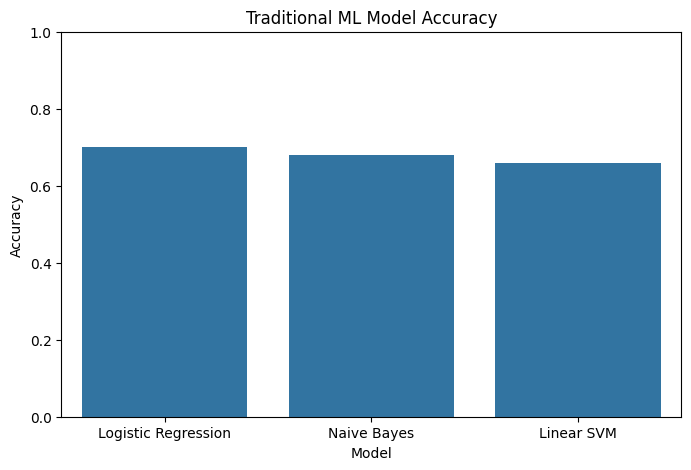

In [2]:

# Load data
df = pd.read_csv("/content/data.csv")

X = df["Sentence"]
y = df["Sentiment"]


# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC()
}

results = []

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    preds = model.predict(X_test_vec)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average="weighted")
    rec = recall_score(y_test, preds, average="weighted")
    f1 = f1_score(y_test, preds, average="weighted")

    results.append([name, acc, prec, rec, f1])

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1:", f1)

# Results table
results_df = pd.DataFrame(
    results, columns=["Model", "Accuracy", "Precision", "Recall", "F1"]
)
print("\nModel Comparison:\n", results_df)

# Accuracy plot
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="Accuracy", data=results_df)
plt.title("Traditional ML Model Accuracy")
plt.ylim(0,1)
plt.show()


nn_lstm_models

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, Flatten, LSTM



In [4]:
# Load data
df = pd.read_csv("data.csv")

X = df["Sentence"]
y = df["Sentiment"]

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Tokenization
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(X)

sequences = tokenizer.texts_to_sequences(X)
padded = pad_sequences(sequences, maxlen=100)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    padded, y_encoded, test_size=0.2, random_state=42
)

# --------------------
# Dense Neural Network
# --------------------
nn_model = Sequential([
    Embedding(10000, 64, input_length=100),
    Flatten(),
    Dense(64, activation="relu"),
    Dense(3, activation="softmax")
])

nn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

nn_model.fit(X_train, y_train, epochs=5, validation_split=0.2)
nn_loss, nn_acc = nn_model.evaluate(X_test, y_test)

print("\nDense NN Accuracy:", nn_acc)

# --------------------
# LSTM Model
# --------------------
lstm_model = Sequential([
    Embedding(10000, 64, input_length=100),
    LSTM(64),
    Dense(3, activation="softmax")
])

lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_model.fit(X_train, y_train, epochs=5, validation_split=0.2)
lstm_loss, lstm_acc = lstm_model.evaluate(X_test, y_test)

print("LSTM Accuracy:", lstm_acc)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - accuracy: 0.5425 - loss: 0.9686 - val_accuracy: 0.5733 - val_loss: 0.9351
Epoch 2/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.7132 - loss: 0.7295 - val_accuracy: 0.6374 - val_loss: 0.8129
Epoch 3/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8778 - loss: 0.3367 - val_accuracy: 0.6193 - val_loss: 0.8308
Epoch 4/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.9161 - loss: 0.1964 - val_accuracy: 0.6182 - val_loss: 0.9869
Epoch 5/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9263 - loss: 0.1381 - val_accuracy: 0.6128 - val_loss: 1.0451
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6802 - loss: 0.9057

Dense NN Accuracy: 0.6578271985054016
Epoch 1/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - accuracy: 0.5633 - loss: 0.9866 - val_accuracy: 0.5947 - val_loss: 0.8930
Epoch 2/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 0.6723 - loss: 0.7669 - val_accuracy: 0.6385 - val_loss:

# FINBERT


In [8]:
import pandas as pd

df = pd.read_csv("data.csv")
print(df.head())
print(df.columns)


                                            Sentence Sentiment
0  The GeoSolutions technology will leverage Bene...  positive
1  $ESI on lows, down $1.50 to $2.50 BK a real po...  negative
2  For the last quarter of 2010 , Componenta 's n...  positive
3  According to the Finnish-Russian Chamber of Co...   neutral
4  The Swedish buyout firm has sold its remaining...   neutral
Index(['Sentence', 'Sentiment'], dtype='object')


In [9]:
from transformers import pipeline

finbert = pipeline(
    "sentiment-analysis",
    model="ProsusAI/finbert"
)


Device set to use cpu


In [10]:
# Optional: limit size for speed
df_sample = df.sample(300, random_state=42)

preds = []

for text in df_sample["Sentence"]:
    result = finbert(text)[0]["label"].lower()
    preds.append(result)

df_sample["predicted"] = preds


In [11]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(df_sample["Sentiment"], df_sample["predicted"])
print("FinBERT Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(df_sample["Sentiment"], df_sample["predicted"]))


FinBERT Accuracy: 0.75

Classification Report:
              precision    recall  f1-score   support

    negative       0.49      0.71      0.58        42
     neutral       0.78      0.79      0.79       162
    positive       0.89      0.70      0.78        96

    accuracy                           0.75       300
   macro avg       0.72      0.73      0.72       300
weighted avg       0.78      0.75      0.76       300



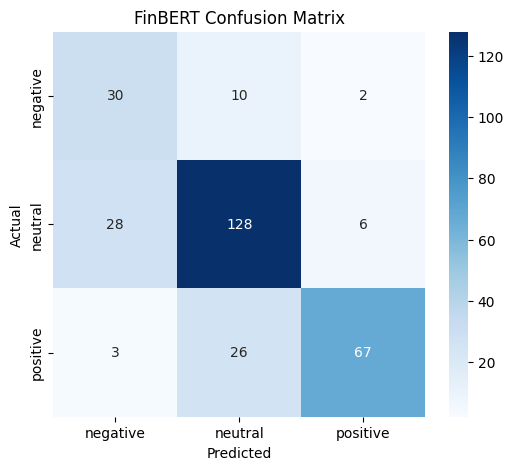

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    df_sample["Sentiment"],
    df_sample["predicted"]
)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["negative", "neutral", "positive"],
    yticklabels=["negative", "neutral", "positive"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("FinBERT Confusion Matrix")
plt.show()
